A notebook for determining and visualizing surgery coordinates!  
All coordinates are with reference to bregma  
  
  Use the brainglobe-env with brainglobe-atlasapi

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from brainglobe_atlasapi import BrainGlobeAtlas

In [55]:
"""Where do we want to go?"""
AP = -3.52
ML = -0.35
DV = -4
"""What angle do we want to use?"""
ML_theta = 10 # in degrees
AP_theta = 0 # in degrees

In [56]:
"""New coordinates of the target point after rotation"""
AP = AP
DV_new = -(np.abs(DV)/np.cos(np.radians(ML_theta))) # hypotenuse
ML_new = (np.abs(ML) + (np.abs(DV_new) * np.sin(np.radians(ML_theta)))) * np.sign(ML) # opposite
print(f"New coordinates at an angle of {ML_theta} degrees: AP = {AP:.2f}, ML = {ML_new:.2f}, DV = {DV_new:.2f}")

New coordinates at an angle of 10 degrees: AP = -3.52, ML = -1.06, DV = -4.06


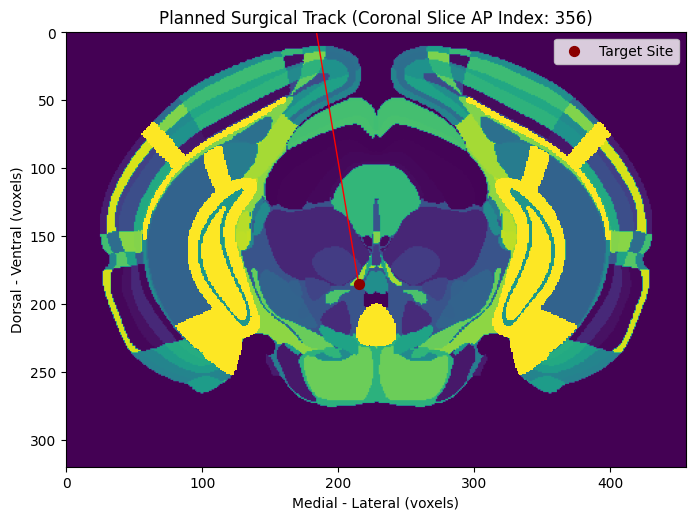

In [42]:
"""Draw the coordinates!"""
atlas = BrainGlobeAtlas("allen_mouse_25um")

# CCFv3.0 coordinates of bregma in voxel space
atlas_bregma_ap = 216
atlas_bregma_dv = 14
atlas_bregma_ml = 228

injection_voxel_ap = atlas_bregma_ap + int(-AP / .025) # if i want to be posterior (-ve) to bregma i need to add to the bregma index
injection_voxel_ml = atlas_bregma_ml + int(ML / .025)
injection_voxel_ml_new = atlas_bregma_ml + int(ML_new / .025)
injection_voxel_dv = atlas_bregma_dv + int(np.abs(DV) / .025)

# draw the triangle to check
fig, ax = plt.subplots(figsize=(8, 6))
coronal_slice = atlas.annotation[injection_voxel_ap, :, :]
ax.imshow(coronal_slice, vmax = 1200)

# mark injection target
ax.scatter(injection_voxel_ml, injection_voxel_dv, color="darkred", s=50, zorder=5, label="Target Site")

# make line for injection angle
ax.plot([injection_voxel_ml_new, injection_voxel_ml], [0, injection_voxel_dv], '-r', lw=1)

ax.set_title(f"Planned Surgical Track (Coronal Slice AP Index: {injection_voxel_ap})")
ax.set_xlabel("Medial - Lateral (voxels)")
ax.set_ylabel("Dorsal - Ventral (voxels)")
plt.legend()
plt.show()

In [ ]:
"""ML leveling coordinates"""
ML_distance = 2 # in mm, total left to right distance between points
print(f"Depth difference between left and right leveling points at {ML_distance} mm apart:")
for i in [-1, 0, 1]:
    depth_diff = np.sin(np.radians(ML_theta + i)) * ML_distance
    print(f"At an angle of {ML_theta + i} degrees: {depth_diff:.2f} mm")

Depth difference between left and right leveling points at 2 mm apart:
At an angle of 9 degrees: 0.31 mm
At an angle of 10 degrees: 0.35 mm
At an angle of 11 degrees: 0.38 mm
